Importing libraries and opening data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('..\\..\\data\\1_Embedded_lies_dataset\\Embedded_lies_manprep.csv', sep=';')
from collections import Counter
import seaborn as sns

ParserError: Error tokenizing data. C error: Expected 131 fields in line 29, saw 132


Split into three groups based on 'type of lie'

In [79]:
# Define the lists of events for each group
none_of_them_list = ['None of them']
personal_gain_list = [
    'A job interview for your dream job',
    'Being hospitalised and undergoing surgery',
    'Being involved in a car accident',
    'Causing a car accident',
    'Getting a speeding fine',
    'Taking the bus/train without the ticket'
]
relational_social_preservation_list = [
    'Cheating on an exam',
    'Cheating on your partner',
    'Ending a long romantic relationship',
    'Missing a deadline at work because of bad organisation',
    'Getting fired'
]

# Create the new dataframes by filtering the 'Event' column
df_none_of_them = df[df['Event'].isin(none_of_them_list)].copy()
df_personal_gain = df[df['Event'].isin(personal_gain_list)].copy()
df_relational_social_preservation = df[df['Event'].isin(relational_social_preservation_list)].copy()

#Create dictionary of dataframes with keys as group names
grouped_dfs = {
    'total': df,
    'none_of_them': df_none_of_them,
    'personal_gain': df_personal_gain,
    'relational_social_preservation': df_relational_social_preservation
}


Plotting age distribution just wanted to see who filled in the forms


C:\Users\20193623\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\20193623\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\20193623\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\20193623\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprec

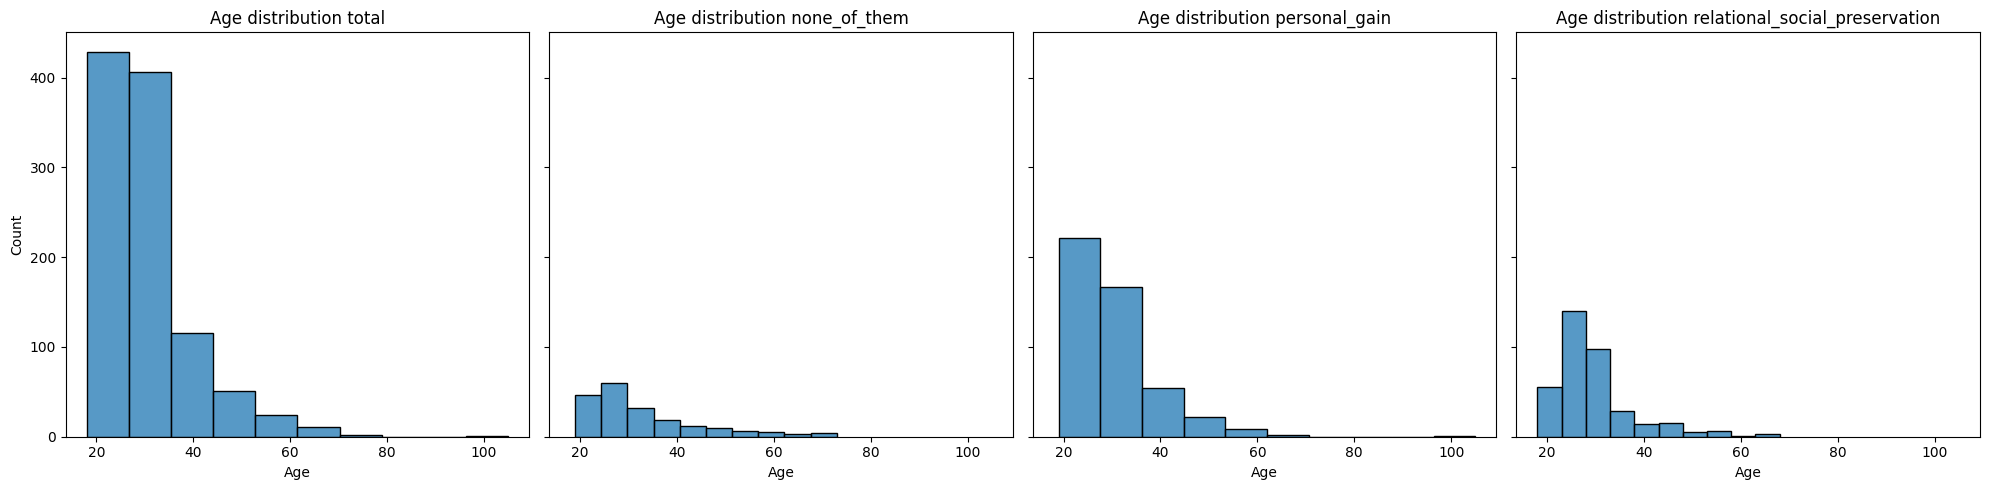

In [86]:
fig, axes = plt.subplots(1, len(grouped_dfs), figsize=(20, 5), sharex=True, sharey=True)  

for ax, (title, dataframe) in zip(axes, grouped_dfs.items()):
        if 'Age' in dataframe.columns:
            sns.histplot(dataframe['Age'], bins=10, kde=False, ax=ax)
            ax.set_title(f'Age distribution {title}')
            ax.set_xlabel('Age')
            ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

Same as above but for nationality, asking about why SA

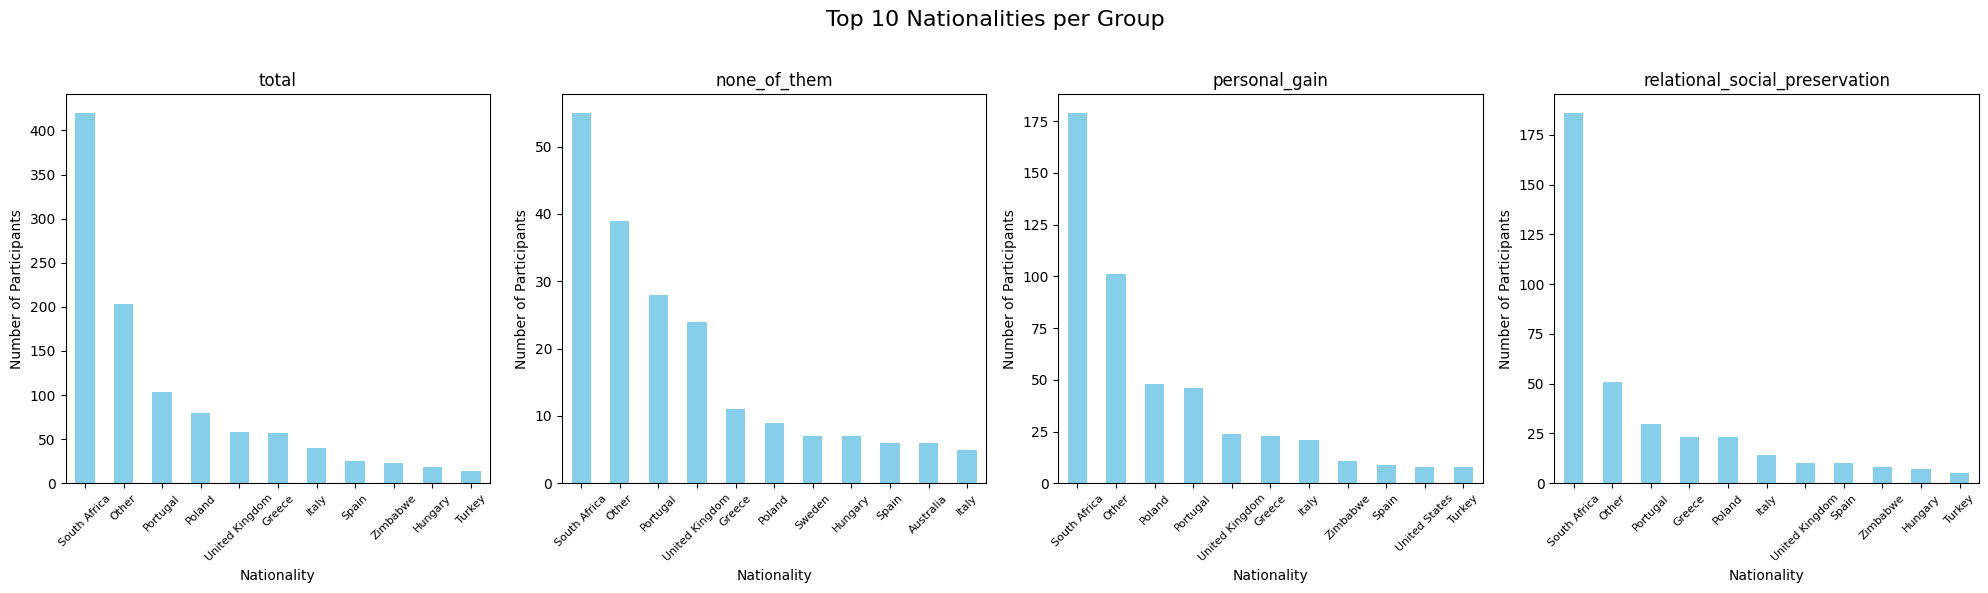

In [87]:



# Create a figure and a set of subplots
fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=False) # sharey=False because we're flipping axes
fig.suptitle('Top 10 Nationalities per Group', fontsize=16)

# Iterate over the dictionary and generate the plots
for ax, (group_name, group_df) in zip(axes, grouped_dfs.items()):
    # Count nationalities
    nationality_counts = group_df['Nationality'].value_counts()
    
    # Select the top 10 and group the rest as 'Other'
    if len(nationality_counts) > 10:
        top_10 = nationality_counts.head(10)
        other = pd.Series(nationality_counts.iloc[10:].sum(), index=['Other'])
        final_counts = pd.concat([top_10, other])
    else:
        final_counts = nationality_counts

    # Create the horizontal bar chart
    final_counts.sort_values(ascending=False).plot(kind='bar', ax=ax, color='skyblue') # Changed to kind='bar'
    ax.set_title(group_name)
    ax.set_xlabel('Nationality') # Flipped
    ax.set_ylabel('Number of Participants') # Flipped
    ax.tick_params(axis='x', rotation=45, labelsize=8) # Rotate x-axis labels for readability

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Percentages

In [70]:
nationaliteit_counts = df['Nationality'].value_counts()
totaal_deelnemers = len(df)
nationaliteit_percentages = (nationaliteit_counts / totaal_deelnemers) * 100
print("Percentages per Nationaliteit:\n")
print(nationaliteit_percentages.round(2).to_string())
    

Percentages per Nationaliteit:

Nationality
South Africa                         40.31
Portugal                              9.98
Poland                                7.68
United Kingdom                        5.57
Greece                                5.47
Italy                                 3.84
Spain                                 2.40
Zimbabwe                              2.21
Hungary                               1.73
Turkey                                1.34
Australia                             1.06
Germany                               1.06
Sweden                                1.06
Ireland                               0.96
United States                         0.86
Estonia                               0.86
France                                0.86
Israel                                0.67
Canada                                0.67
Nigeria                               0.58
Czech Republic                        0.58
Slovenia                              0.58
Belgium   

Simple word count per group

C:\Users\20193623\AppData\Local\Temp\ipykernel_20080\1212274631.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(top_df["word"], rotation=45, ha="right")


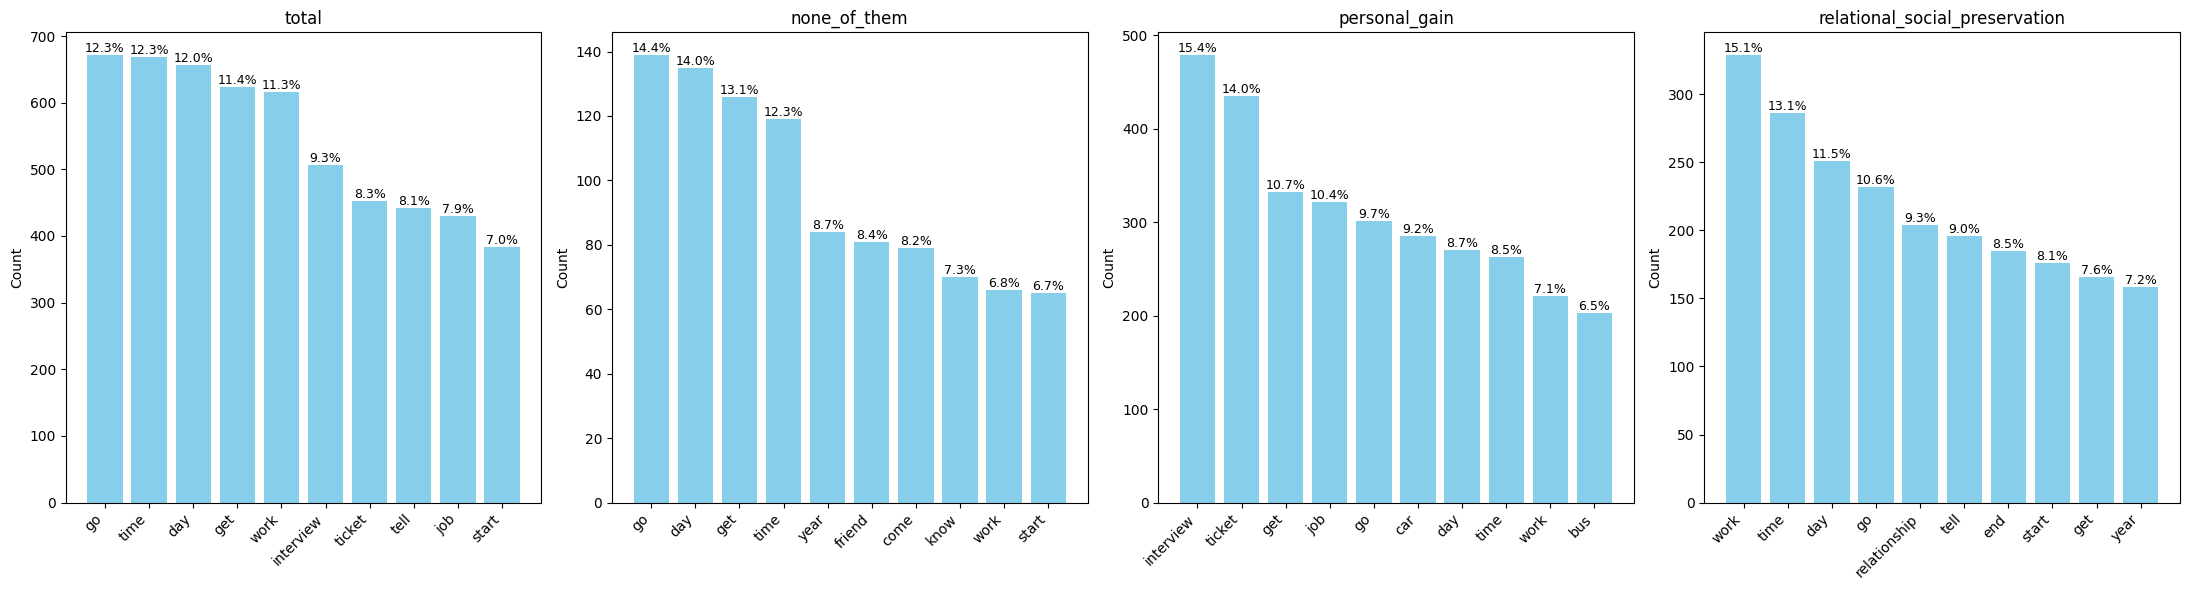

In [90]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

for ax, (name, top_df) in zip(axes, dfs_top10.items()):
    total = top_df["count"].sum()
    top_df["perc"] = (top_df["count"] / total) * 100

    bars = ax.bar(top_df["word"], top_df["count"], color="skyblue")

    # Annotaties met percentages
    for bar, perc in zip(bars, top_df["perc"]):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2, height,
            f"{perc:.1f}%", ha="center", va="bottom", fontsize=9
        )

    ax.set_title(name)
    ax.set_ylabel("Count")
    ax.set_xticklabels(top_df["word"], rotation=45, ha="right")

plt.tight_layout()
plt.show()


CDF wordcount


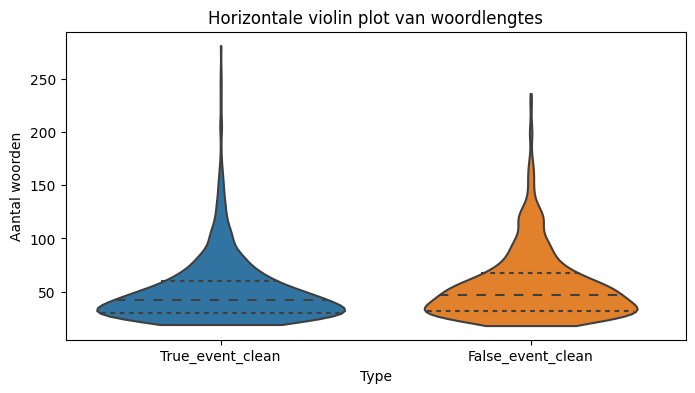

        True_event_clean  False_event_clean
count            1042.00            1042.00
mean               50.75              55.40
std                31.05              32.53
min                19.00              18.00
25%                30.25              32.00
50%                42.00              47.00
75%                60.00              67.00
max               281.00             236.00
median             42.00              47.00


In [113]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Lengtes berekenen
true_len = df["True_event_clean"].dropna().astype(str).apply(lambda x: len(x.split()))
false_len = df["False_event_clean"].dropna().astype(str).apply(lambda x: len(x.split()))


# Combineer in één DataFrame
lens_df = pd.DataFrame({
    "True_event_clean": true_len,
    "False_event_clean": false_len
}).melt(var_name="Type", value_name="Word_count")


plt.figure(figsize=(8,4))
sns.violinplot(data=lens_df, x="Type", y="Word_count", inner="quartile", cut=0, fill=True)
plt.title("Horizontale violin plot van woordlengtes")
plt.xlabel("Type")
plt.ylabel("Aantal woorden")
plt.show()

stats = pd.DataFrame({
    "True_event_clean": true_len.describe().round(2),
    "False_event_clean": false_len.describe().round(2)
})

# Mediaan expliciet toevoegen
stats.loc["median"] = [true_len.median(), false_len.median()]

print(stats)

Very similar


In [ ]:
true_arr = true_len.values
false_arr = false_len.values
mean_diff = false_arr.mean() - true_arr.mean()
pooled_std = np.sqrt(((true_arr.std(ddof=1) ** 2) + (false_arr.std(ddof=1) ** 2)) / 2)
cohens_d = mean_diff / pooled_std

print("Cohen's d:", round(cohens_d, 3)) 


Cohen's d: 0.146


small effect https://statisticsbyjim.com/basics/cohens-d